## Customer Churn Prediction using Machine Learning

## Project Overview

This project aims to predict whether a customer is likely to churn based on demographic and behavioral information. Multiple machine learning algorithms are evaluated, and the best-performing model is selected to help businesses identify at-risk customers and improve customer retention strategies.

## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Load the Dataset

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Initial Data Exploration

The dataset is explored to understand its structure, dimensions, column names, and basic statistics.

In [3]:
print(df.shape)
print(df.columns)

(7043, 21)
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Check for Missing Values

In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

## Exploratory Data Analysis

Visualizations are created to understand customer behavior, churn patterns, and relationships between important features.

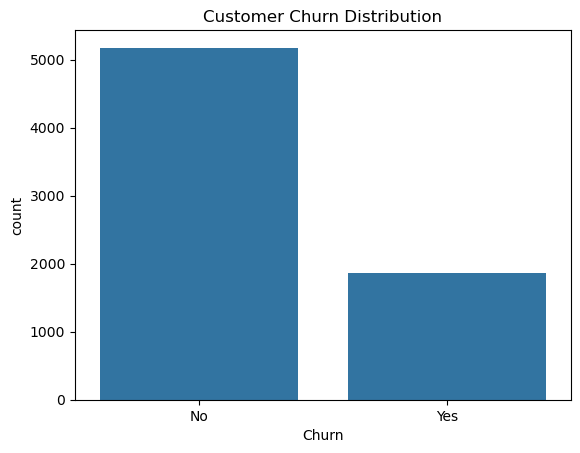

In [9]:
sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")
plt.show()

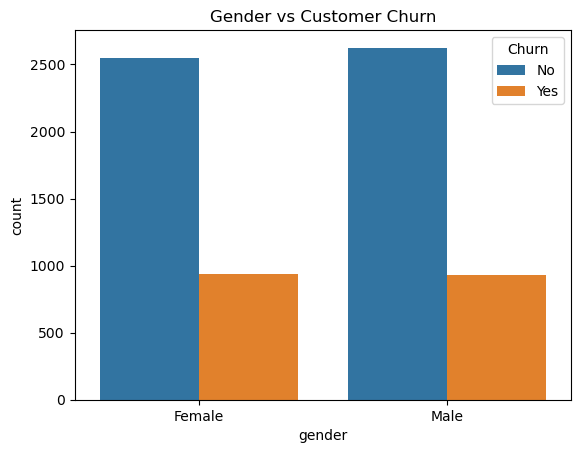

In [10]:
sns.countplot(x="gender", hue="Churn", data=df)

plt.title("Gender vs Customer Churn")
plt.show()

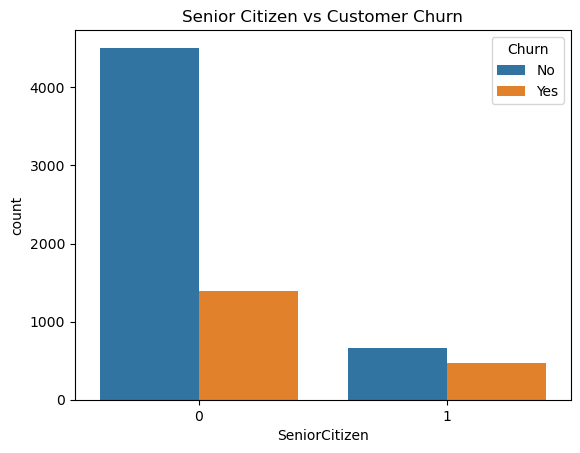

In [11]:
sns.countplot(x="SeniorCitizen", hue="Churn", data=df)

plt.title("Senior Citizen vs Customer Churn")
plt.show()

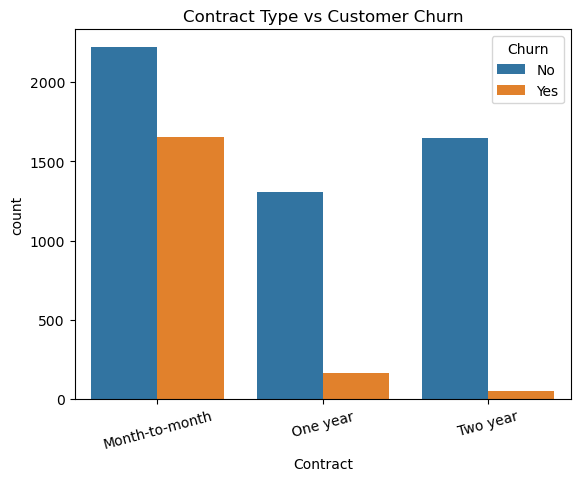

In [12]:
sns.countplot(x="Contract", hue="Churn", data=df)

plt.title("Contract Type vs Customer Churn")
plt.xticks(rotation=15)

plt.show()

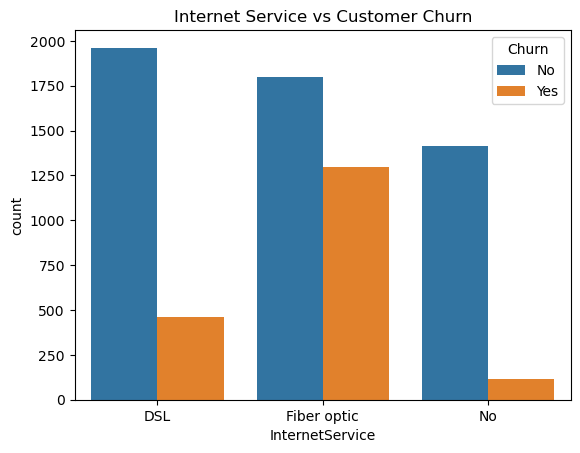

In [13]:
sns.countplot(x="InternetService", hue="Churn", data=df)

plt.title("Internet Service vs Customer Churn")

plt.show()

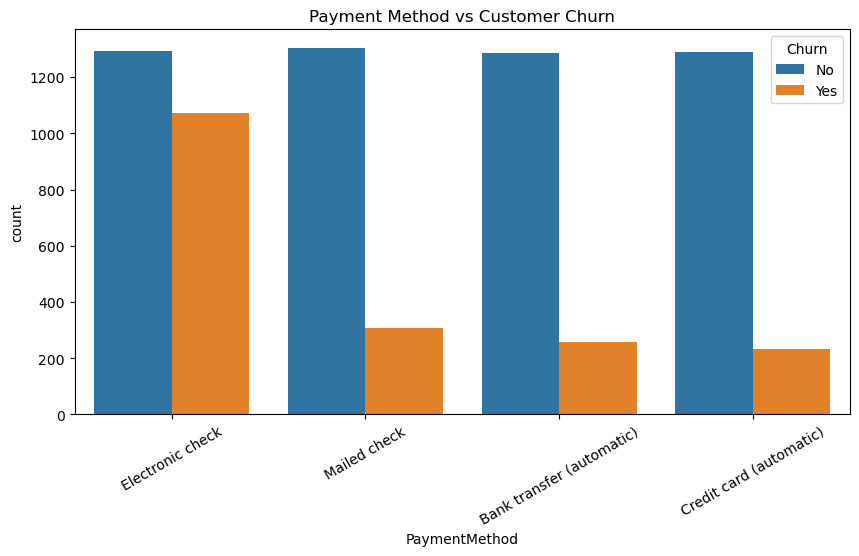

In [14]:
plt.figure(figsize=(10,5))

sns.countplot(
    x="PaymentMethod",
    hue="Churn",
    data=df
)

plt.xticks(rotation=30)

plt.title("Payment Method vs Customer Churn")

plt.show()

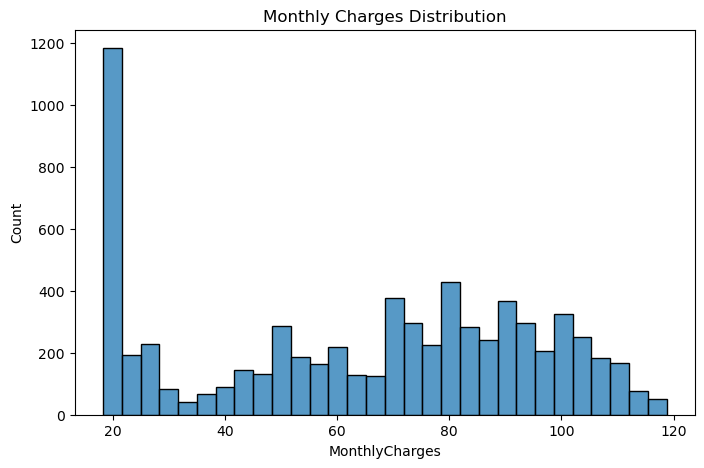

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(df["MonthlyCharges"], bins=30)

plt.title("Monthly Charges Distribution")

plt.show()

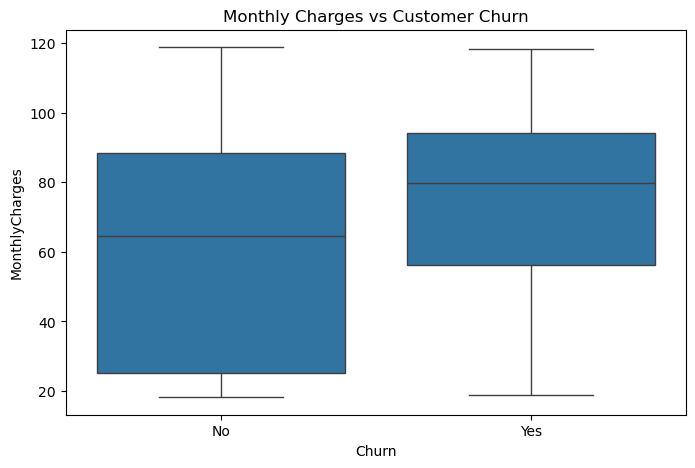

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.title("Monthly Charges vs Customer Churn")

plt.show()

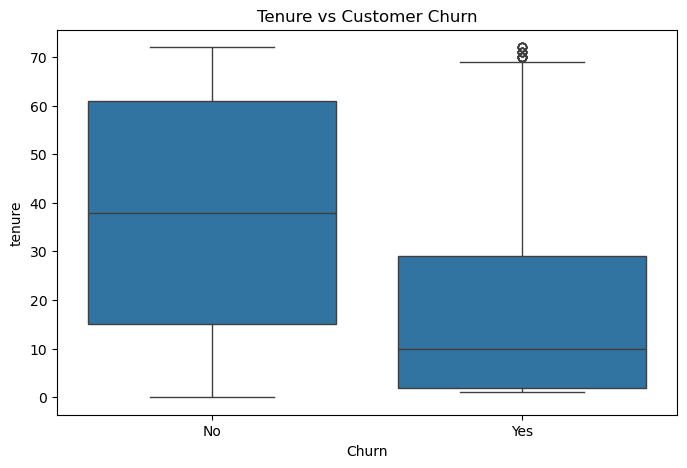

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="tenure",
    data=df
)

plt.title("Tenure vs Customer Churn")

plt.show()

In [18]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

## Data Cleaning

The dataset is cleaned by handling data type inconsistencies, removing missing values, dropping irrelevant features, and preparing the target variable for machine learning.

In [19]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [20]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [21]:
df.dropna(inplace=True)

In [22]:
df.drop('customerID', axis=1, inplace=True)

In [23]:
df['Churn'] = df['Churn'].map({
    'No':0,
    'Yes':1
})

In [24]:
df['Churn'].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

## Encode Categorical Features

Categorical variables are converted into numerical format using one-hot encoding so they can be used by machine learning algorithms.

In [25]:
df = pd.get_dummies(
    df,
    drop_first=True
)

## Feature Engineering

A new feature called AvgMonthlySpend is created to capture customer spending behavior and potentially improve model performance.

In [26]:
df["AvgMonthlySpend"] = (
    df["TotalCharges"] / (df["tenure"] + 1)
)

In [27]:
X = df.drop('Churn', axis=1)

y = df['Churn']

In [28]:
print(X.shape)
print(y.shape)

(7032, 31)
(7032,)


In [29]:
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,AvgMonthlySpend
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,14.925000
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,53.985714
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,36.050000
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,40.016304
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,50.550000


## Split the Dataset

The dataset is divided into training and testing sets to evaluate the model on unseen data.

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Feature Scaling

Numerical features are standardized using StandardScaler to ensure all features contribute equally during model training.

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Train Machine Learning Models

Multiple classification algorithms are trained and compared to identify the best-performing model.

In [32]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

In [33]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [34]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

knn_pred = knn.predict(X_test_scaled)

In [35]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

## Compare Model Performance

The performance of different machine learning algorithms is compared using accuracy scores.

In [36]:
from sklearn.metrics import accuracy_score

results = {
    "Logistic Regression": accuracy_score(y_test, lr_pred),
    "Decision Tree": accuracy_score(y_test, dt_pred),
    "KNN": accuracy_score(y_test, knn_pred),
    "Random Forest": accuracy_score(y_test, rf_pred),
}

for model, score in results.items():
    print(f"{model}: {score:.4f}")

Logistic Regression: 0.7974
Decision Tree: 0.7299
KNN: 0.7484
Random Forest: 0.7946


In [37]:
results_df = pd.DataFrame({
    "Model": results.keys(),
    "Accuracy": results.values()
})

results_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
0,Logistic Regression,0.797441
3,Random Forest,0.794598
2,KNN,0.748401
1,Decision Tree,0.729922


## Hyperparameter Tuning

GridSearchCV is used to optimize the Logistic Regression model by searching for the best combination of hyperparameters.

In [38]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    "solver": ["liblinear", "lbfgs", "newton-cg"],
    "class_weight": [None, "balanced"]
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000), n_jobs=-1,
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
                         'class_weight': [None, 'balanced'],
                         'solver': ['liblinear', 'lbfgs', 'newton-cg']},
             scoring='accuracy')

## Model Evaluation

The final model is evaluated using accuracy, confusion matrix, and classification report to measure its predictive performance.

In [39]:
print(grid_search.best_params_)

{'C': 1, 'class_weight': None, 'solver': 'liblinear'}


In [40]:
best_lr = grid_search.best_estimator_

In [41]:
y_pred = best_lr.predict(X_test_scaled)

In [42]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7960199004975125


In [43]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1033
           1       0.65      0.50      0.56       374

    accuracy                           0.80      1407
   macro avg       0.74      0.70      0.72      1407
weighted avg       0.78      0.80      0.79      1407



In [44]:
print(confusion_matrix(y_test, y_pred))

[[934  99]
 [188 186]]


## Save the Trained Model

The trained model is saved using Pickle so that it can be reused without retraining.

In [45]:
import pickle

with open("customer_churn_model.pkl", "wb") as file:
    pickle.dump(best_lr, file)

## Save the Feature Scaler

The fitted scaler is saved to ensure consistent preprocessing during future predictions.

In [46]:
with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

## Test on New Customer Data

The saved model is tested on unseen customer data to verify its real-world prediction capability.

In [47]:
new_customer = X.iloc[[0]]

prediction = best_lr.predict(
    scaler.transform(new_customer)
)

print(prediction)

[1]


## Business Insights

- Customers with Month-to-Month contracts exhibit the highest churn rate.
- Customers using Fiber Optic internet service are more likely to leave the service.
- Customers with higher monthly charges tend to churn more frequently.
- Long-term customers show lower churn rates, indicating customer loyalty increases with tenure.
- Businesses can reduce churn by encouraging long-term contracts and improving customer satisfaction among high-risk groups.

## Conclusion

Multiple machine learning algorithms were evaluated for customer churn prediction. Logistic Regression achieved the best overall performance and was selected as the final model. The project demonstrates data preprocessing, feature engineering, model comparison, hyperparameter tuning, and evaluation techniques that can help businesses proactively identify customers at risk of churning.